In [83]:
#importing the dataset
from ucimlrepo import fetch_ucirepo 
import numpy as np
import pandas as pd

In [84]:
#fetching the dataset
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# Combine them into a single DataFrame
df = pd.concat([X, y], axis=1)
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [86]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [87]:
#dropping the null rows
df=df.dropna(axis=0)
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

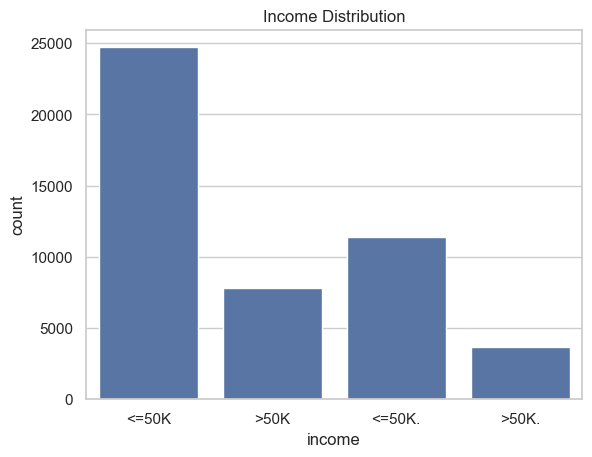

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target variable distribution
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

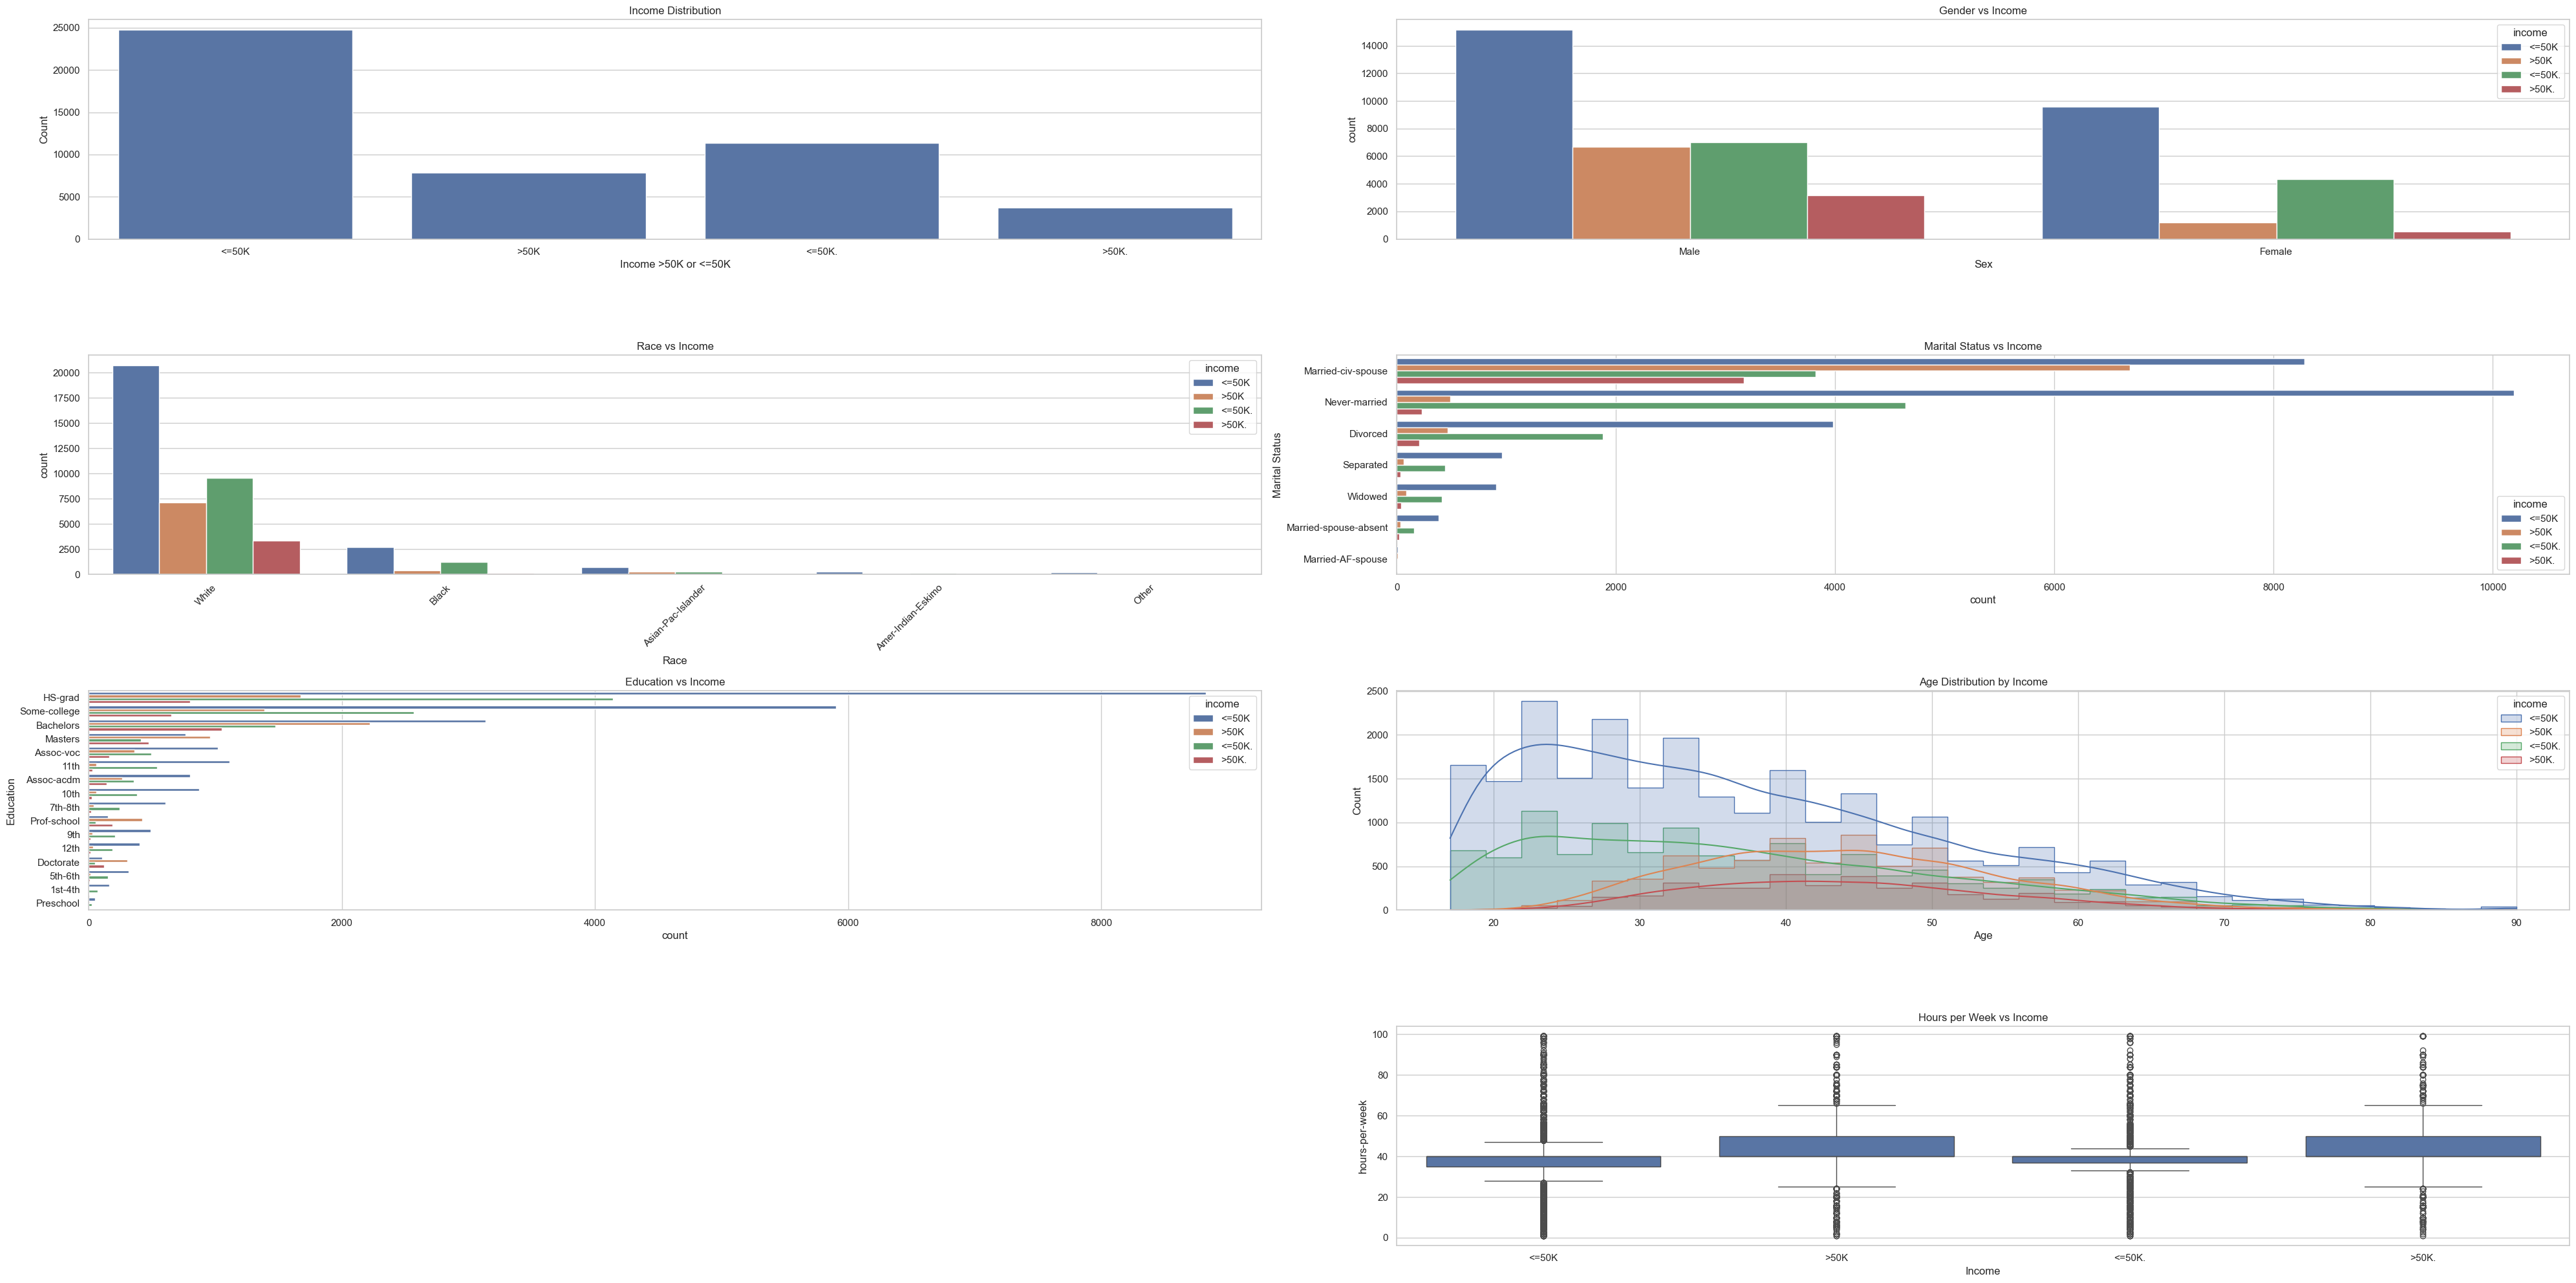

In [89]:
#different graphs
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(40, 20))

# 1. Income Distribution
plt.subplot(4, 2, 1)
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.xlabel("Income >50K or <=50K")
plt.ylabel("Count")

# 2. Gender vs Income
plt.subplot(4, 2, 2)
sns.countplot(x='sex', hue='income', data=df)
plt.title("Gender vs Income")
plt.xlabel("Sex")

# 3. Race vs Income
plt.subplot(4, 2, 3)
sns.countplot(x='race', hue='income', data=df)
plt.title("Race vs Income")
plt.xlabel("Race")
plt.xticks(rotation=45)

# 4. Marital Status vs Income
plt.subplot(4, 2, 4)
sns.countplot(y='marital-status', hue='income', data=df, order=df['marital-status'].value_counts().index)
plt.title("Marital Status vs Income")
plt.ylabel("Marital Status")

# 5. Education vs Income
plt.subplot(4, 2, 5)
sns.countplot(y='education', hue='income', data=df, order=df['education'].value_counts().index)
plt.title("Education vs Income")
plt.ylabel("Education")



# 7. Age Distribution by Income income
plt.subplot(4, 2, 6)
sns.histplot(data=df, x='age', hue='income', bins=30, kde=True, element='step')
plt.title("Age Distribution by Income")
plt.xlabel("Age")

# 8. Hours per Week vs Income (Box Plot)
plt.subplot(4, 2, 8)
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title("Hours per Week vs Income")
plt.xlabel("Income")

plt.tight_layout()
plt.show()


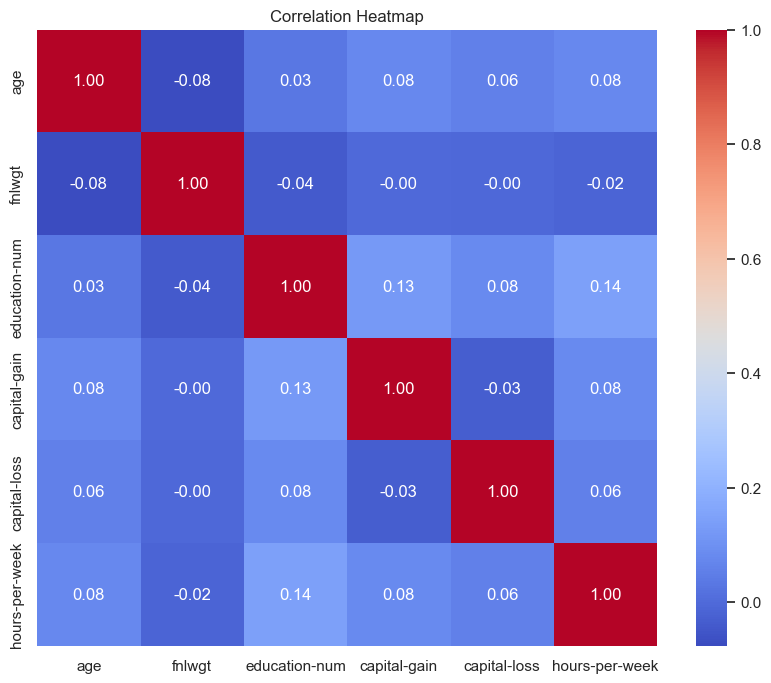

In [90]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [91]:
#AS we can see that there are four column with two identical values
#we need to change them to two columns 
df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [92]:
df['workclass'].unique()


array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [93]:
#dropping rows in workclass where '?'
df = df[df['workclass'] != '?'].copy()

In [94]:
def map_employment(x):
    if x.endswith('-gov'):
        return 'Government'
    elif x.startswith('Self-emp'):
        return 'Self-employed'
    elif x in [ 'Without-pay', 'Never-worked']:
        return 'Unemployed'
    else:
        return x  # fallback just in case

df['employment_grouped'] = df['workclass'].apply(map_employment)


In [95]:
print(df['employment_grouped'].value_counts())

employment_grouped
Private          33717
Government        6514
Self-employed     5526
Unemployed          28
Name: count, dtype: int64


In [96]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['employment_num'] = le.fit_transform(df['employment_grouped'])

In [97]:
def map_education(x):
    lower_secondary = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th']
    higher_secondary = ['11th', '12th', 'HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors = ['Bachelors']
    masters_and_above = ['Masters', 'Prof-school', 'Doctorate']
    if x in lower_secondary:
        return 'Lower Secondary'
    elif x in higher_secondary:
        return 'Higher Secondary'
    elif x in some_college:
        return 'Some College'
    elif x in bachelors:
        return 'Bachelors'
    elif x in masters_and_above:
        return 'Masters and above'
    else:
        return 'Other'  # fallback  # fallback just in case

df['education_grouped'] = df['education'].apply(map_education)

In [98]:
le = LabelEncoder()
df['education_num'] = le.fit_transform(df['education_grouped'])

In [99]:
df['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

In [100]:
def marital_status_education(x):
    In_relation = ['Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse']
    single = ['Never-married', 'Divorced', 'Separated-grad', 'Widowed']
    if x in In_relation:
        return 'In Relation'
    elif x in single:
        return 'Single'
    else:
        return 'Other'  # fallback  # fallback just in case

df['marriage_grouped'] = df['marital-status'].apply(marital_status_education)

In [101]:
df = df[df['marriage_grouped'] != 'Other'].copy()

In [102]:
le = LabelEncoder()
df['marital_num'] = le.fit_transform(df['marriage_grouped'])

In [103]:
df = df[df['occupation'] != '?'].copy()
df['occupation_encoded'] = le.fit_transform(df['occupation'])


In [104]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'employment_grouped', 'employment_num', 'education_grouped',
       'education_num', 'marriage_grouped', 'marital_num',
       'occupation_encoded'],
      dtype='object')

In [105]:
df.drop(['fnlwgt', 'education', 'education-num',  'marital-status', 'occupation', 'relationship', 'race','capital-gain', 'capital-loss', 'hours-per-week', 'native-country','employment_grouped','education_grouped','marriage_grouped'], axis=1, inplace=True)
df.head()

,age,workclass,sex,income,employment_num,education_num,marital_num,occupation_encoded
0,39,State-gov,Male,<=50K,0,0,1,0
1,50,Self-emp-not-inc,Male,<=50K,2,0,0,3
2,38,Private,Male,<=50K,1,1,1,5
3,53,Private,Male,<=50K,1,1,0,5
4,28,Private,Female,<=50K,1,0,0,9


In [107]:
#Using label encoder for binary columns 
le=LabelEncoder()
df['sex'] = le.fit_transform(df['sex']) 


In [108]:

#Encoding target variable ('income') to binary
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

print(df.head())


   age         workclass  sex  income  employment_num  education_num  \
0   39         State-gov    1       0               0              0   
1   50  Self-emp-not-inc    1       0               2              0   
2   38           Private    1       0               1              1   
3   53           Private    1       0               1              1   
4   28           Private    0       0               1              0   

   marital_num  occupation_encoded  
0            1                   0  
1            0                   3  
2            1                   5  
3            0                   5  
4            0                   9  


In [109]:
df['workclass'] = le.fit_transform(df['workclass']) 

In [113]:
from sklearn.model_selection import train_test_split
X = df.drop('income', axis=1)
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [120]:
#importing different models"from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [121]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [122]:
results = {}
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

c:\Users\Nhujaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nhujaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:11:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                     Accuracy  Precision    Recall  F1 Score
Gradient Boosting    0.835175   0.712984  0.566516  0.631367
XGBoost              0.826945   0.677538  0.582805  0.626612
Random Forest        0.803044   0.609976  0.580995  0.595133
Naive Bayes          0.747576   0.495439  0.712670  0.584524
Decision Tree        0.796505   0.602949  0.536652  0.567872
KNN                  0.794814   0.598584  0.535747  0.565425
Logistic Regression  0.744870   0.477523  0.254751  0.332251
SVM                  0.750846   0.000000  0.000000  0.000000


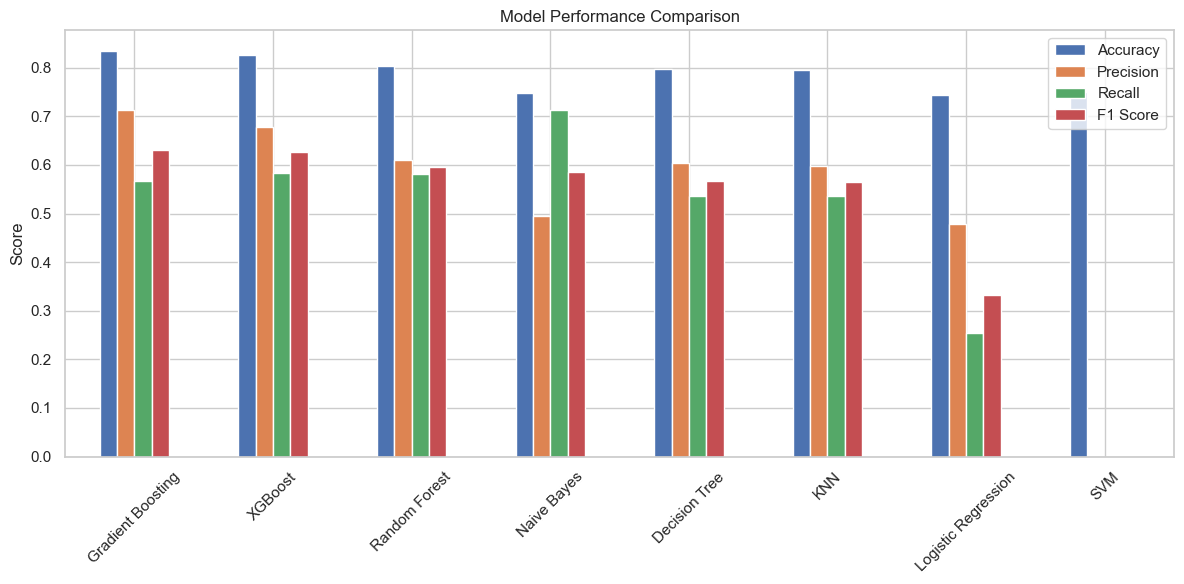

In [123]:
results_df = pd.DataFrame(results).T.sort_values(by='F1 Score', ascending=False)
print(results_df)

# Visualize
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

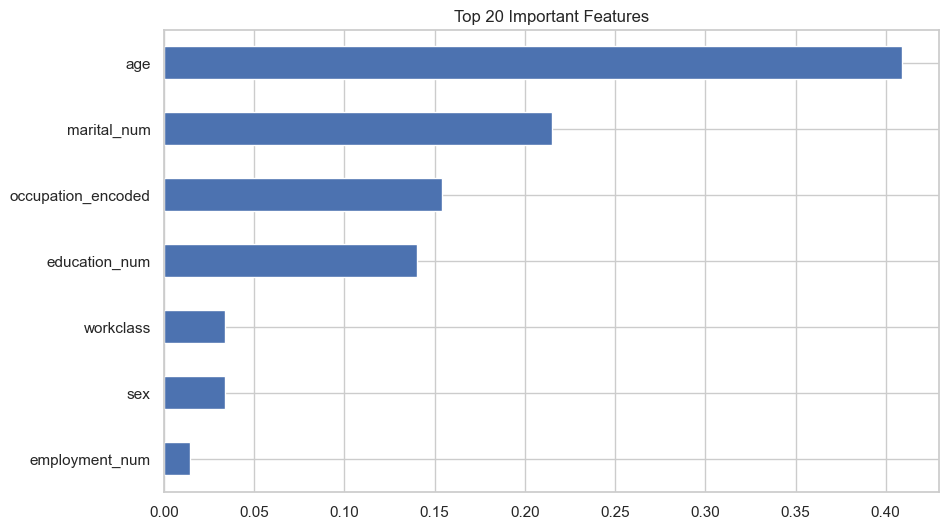

In [124]:
importances = models['Random Forest'].feature_importances_
features = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot
features.head(20).plot(kind='barh', figsize=(10, 6))
plt.title("Top 20 Important Features")
plt.gca().invert_yaxis()
plt.show()

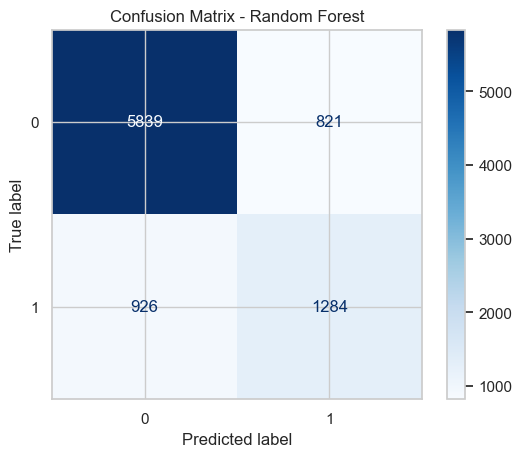

In [125]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models['Random Forest'], X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()


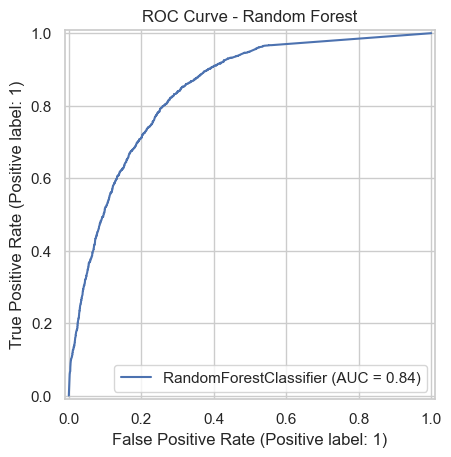

In [126]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(models['Random Forest'], X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

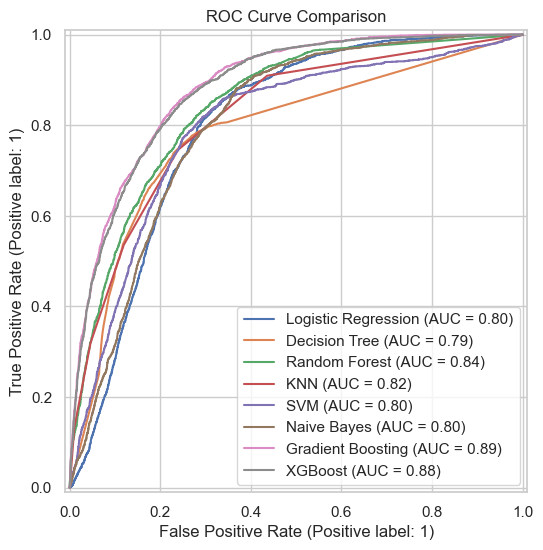

In [127]:
plt.figure(figsize=(10, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())

plt.title("ROC Curve Comparison")
plt.show()
